In [10]:
import pandas as pd 
df = pd.read_csv("dfAll.csv")

df.head()

,Rk_x,Player,Nation_x,Pos_x,Squad_x,Age_x,Weekly Wages,Annual Wages,Annual EUR,Annual GBP,...,npxG.1,npxG+xAG.1,Matches,Predicted Salary,Ratio,League,Notes,Rk,k,log salary
0,1.0,Lionel Messi,ar ARG,"FW,MF",Inter Miami,37,"$230,769 (€ 199,448, £ 176,151)","$12,000,000 (€ 10,371,314, £ 9,159,866)",10371314.0,9159866.0,...,0.78,1.30,Matches,3.473915e+07,3.349542,MLS,NaN,NaN,NaN,NaN
1,2.0,Son Heung-min,kr KOR,FW,LAFC,32,"$199,399 (€ 172,336, £ 152,206)","$10,368,750 (€ 8,961,464, £ 7,914,697)",8961464.0,7914697.0,...,0.59,0.93,Matches,1.575144e+07,1.757686,MLS,NaN,NaN,NaN,NaN
2,3.0,Sergio Busquets,es ESP,MF,Inter Miami,36,"$163,461 (€ 141,276, £ 124,774)","$8,499,996 (€ 7,346,344, £ 6,488,235)",7346344.0,6488235.0,...,0.01,0.21,Matches,1.214806e+07,1.653620,MLS,NaN,NaN,NaN,NaN
3,4.0,Miguel Almirón,py PAR,"FW,MF",Atlanta Utd,30,"$116,462 (€ 100,655, £ 88,898)","$6,056,000 (€ 5,234,057, £ 4,622,679)",5234057.0,4622679.0,...,0.22,0.32,Matches,1.457778e+07,2.785179,MLS,NaN,NaN,NaN,NaN
4,5.0,Hirving Lozano,mx MEX,FW,San Diego FC,29,"$115,385 (€ 99,724, £ 88,076)","$6,000,000 (€ 5,185,657, £ 4,579,933)",5185657.0,4579933.0,...,0.42,0.64,Matches,1.460957e+07,2.817303,MLS,NaN,NaN,NaN,NaN


In [5]:
df = pd.read_csv("dfAll.csv")

df_clean = df[[
    "Player",
    "Nation_x",
    "Pos_x",
    "Squad_x",
    "Age_x",
    "Weekly Wages"
]]

df_clean.head()

,Player,Nation_x,Pos_x,Squad_x,Age_x,Weekly Wages
0,Lionel Messi,ar ARG,"FW,MF",Inter Miami,37,"$230,769 (€ 199,448, £ 176,151)"
1,Son Heung-min,kr KOR,FW,LAFC,32,"$199,399 (€ 172,336, £ 152,206)"
2,Sergio Busquets,es ESP,MF,Inter Miami,36,"$163,461 (€ 141,276, £ 124,774)"
3,Miguel Almirón,py PAR,"FW,MF",Atlanta Utd,30,"$116,462 (€ 100,655, £ 88,898)"
4,Hirving Lozano,mx MEX,FW,San Diego FC,29,"$115,385 (€ 99,724, £ 88,076)"


In [8]:
import re

def extract_euro(value):
    if pd.isna(value):
        return None
    
    match = re.search(r'€\s*([\d,]+)', str(value))
    
    if match:
        return int(match.group(1).replace(',', ''))
    
    return None

df_clean['Weekly_Wages_EUR'] = df_clean['Weekly Wages'].apply(extract_euro)

df_clean[['Weekly Wages', 'Weekly_Wages_EUR']].head()


/var/folders/x8/js96pkk57cjfrx8wdb41b9040000gn/T/ipykernel_43644/1890328576.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Weekly_Wages_EUR'] = df_clean['Weekly Wages'].apply(extract_euro)


,Weekly Wages,Weekly_Wages_EUR
0,"$230,769 (€ 199,448, £ 176,151)",199448
1,"$199,399 (€ 172,336, £ 152,206)",172336
2,"$163,461 (€ 141,276, £ 124,774)",141276
3,"$116,462 (€ 100,655, £ 88,898)",100655
4,"$115,385 (€ 99,724, £ 88,076)",99724


In [11]:
df_clean = df[[
    "Player",
    "Nation_x",
    "Pos_x",
    "Squad_x",
    "Age_x",
    "Weekly Wages"
]].copy()

In [13]:
df_clean['Weekly_Wages_EUR'] = df_clean['Weekly Wages'].apply(extract_euro)


In [14]:
import re

def extract_euro(value):
    if pd.isna(value):
        return None
    
    match = re.search(r'€\s*([\d,]+)', str(value))
    
    if match:
        return int(match.group(1).replace(',', ''))
    
    return None

df_clean['Weekly_Wages_EUR'] = df_clean['Weekly Wages'].apply(extract_euro)

df_clean[['Weekly Wages', 'Weekly_Wages_EUR']].head()

,Weekly Wages,Weekly_Wages_EUR
0,"$230,769 (€ 199,448, £ 176,151)",199448
1,"$199,399 (€ 172,336, £ 152,206)",172336
2,"$163,461 (€ 141,276, £ 124,774)",141276
3,"$116,462 (€ 100,655, £ 88,898)",100655
4,"$115,385 (€ 99,724, £ 88,076)",99724


In [19]:
df_clean['Nation_clean']=df_clean['Nation_x'].str.split().str[-1]
df_clean[['Nation_x','Nation_clean']].head()
#Convertir abreviado de nación "ar ARG" -> "ARG"

,Nation_x,Nation_clean
0,ar ARG,ARG
1,kr KOR,KOR
2,es ESP,ESP
3,py PAR,PAR
4,mx MEX,MEX


In [25]:
def position_group(pos):
    if isinstance(pos,str):
        if 'FW' in pos:
            return 'Delantero'
        elif 'MF' in pos:
            return 'Mediocampista'
        elif 'DF' in pos:
            return 'Defensa'
        elif 'GK' in pos:
            return 'Arquero'
        else:
            return 'Desconocido'
    else:
        return 'Desconocido'  # Se ha añadido la gestión de entradas que no sean cadenas de texto.

df_clean['Position_group']=df_clean['Pos_x'].apply(position_group)
df_clean[['Pos_x','Position_group']].head()  # Mayúsculas fijas para que coincidan con el nombre de la columna.

,Pos_x,Position_group
0,"FW,MF",Delantero
1,FW,Delantero
2,MF,Mediocampista
3,"FW,MF",Delantero
4,FW,Delantero


In [26]:

df_clean['Age']=df_clean['Age_x']

In [27]:
df_clean.isnull().sum()

Player               0
Nation_x            41
Pos_x               10
Squad_x              0
Age_x                0
Weekly Wages         0
Weekly_Wages_EUR     0
Nation_clean        41
Position_group       0
Age                  0
dtype: int64

In [29]:
df_clean=df_clean.dropna(subset=['Nation_clean'])

In [31]:
df_clean.loc[:,'Position_group']=df_clean['Position_group'].fillna('Desconocido')

In [32]:
df_clean.isnull().sum()

Player               0
Nation_x             0
Pos_x               10
Squad_x              0
Age_x                0
Weekly Wages         0
Weekly_Wages_EUR     0
Nation_clean         0
Position_group       0
Age                  0
dtype: int64

In [33]:
#¿Que posición gana más?
df_clean.groupby('Position_group')['Weekly_Wages_EUR'].mean().sort_values(ascending=False)

Position_group
Desconocido      93590.818182
Delantero        58403.336892
Mediocampista    54961.425901
Defensa          52491.712426
Arquero          45052.666667
Name: Weekly_Wages_EUR, dtype: float64

In [34]:
df_filtrado=df_clean[df_clean['Position_group']!='Desconocido']
#Se excluyeron categorías con baja representatividad (“Desconocido”) para evitar sesgos en el análisis de salarios.

In [35]:
df_filtrado.groupby('Position_group')['Weekly_Wages_EUR'].mean().sort_values(ascending=False)

Position_group
Delantero        58403.336892
Mediocampista    54961.425901
Defensa          52491.712426
Arquero          45052.666667
Name: Weekly_Wages_EUR, dtype: float64

In [36]:
#Los delanteros presentan el mayor salario promedio dentro del dataset, lo que sugiere que el mercado futbolístico prioriza jugadores con impacto ofensivo directo, ya que su desempeño influye directamente en los resultados de los partidos.

In [37]:
df_filtrado.groupby('Nation_clean')['Weekly_Wages_EUR'].mean().sort_values(ascending=False).head(10)

Nation_clean
EGY    325860.250000
KOR    121450.125000
GEO    120160.166667
SVN    111915.875000
NED    106840.063492
CTA    104808.000000
POR    101590.094340
ENG     96951.680000
NOR     93964.700000
ARM     93654.000000
Name: Weekly_Wages_EUR, dtype: float64

In [38]:
df_filtrado[df_filtrado['Nation_clean'] == 'EGY'].shape

(4, 10)

In [41]:
conteo_paises = df_filtrado['Nation_clean'].value_counts()

paises_validos = conteo_paises[conteo_paises > 10].index

df_paises = df_filtrado[df_filtrado['Nation_clean'].isin(paises_validos)]

df_paises.groupby('Nation_clean')['Weekly_Wages_EUR'].mean().sort_values(ascending=False).head(10)

#Corrección para conocer que paises poseen los jugadores con mejores salarios 

Nation_clean
NED    106840.063492
POR    101590.094340
ENG     96951.680000
NOR     93964.700000
BRA     87316.082474
POL     83567.500000
AUT     82077.300000
TUR     74611.187500
FRA     73702.369458
BEL     72565.695652
Name: Weekly_Wages_EUR, dtype: float64

In [40]:
#Tras filtrar países con baja representatividad, Países Bajos presenta el mayor salario promedio, lo que sugiere una alta concentración de jugadores en ligas competitivas con estructuras salariales elevadas.

In [43]:
df_filtrado.groupby('Squad_x')['Weekly_Wages_EUR'].mean().sort_values(ascending=False).head(10)
#¿Que equipos pagan más?

Squad_x
Real Madrid        242263.093023
Bayern Munich      214070.500000
Manchester City    198491.184211
Liverpool          179405.290323
Arsenal            170387.371429
Barcelona          167530.681818
Paris S-G          156230.857143
Manchester Utd     145051.809524
Aston Villa        125753.315789
Atlético Madrid    123341.325000
Name: Weekly_Wages_EUR, dtype: float64

In [45]:
#Los equipos con mayor salario promedio son Real Madrid, Bayern Munich y Manchester City, lo que refleja su alto poder financiero y su capacidad para atraer y retener talento de élite en el fútbol mundial.

In [66]:
#Relación salario y edad de jugadores 

def age_group(age):
    if age <= 21:
        return 'Joven'
    if age <= 26:
        return 'Prime'
    if age <= 33:
        return 'Mayor'
    else:
        return 'Veterano'

df_clean.loc[:,'Age_group'] = df_clean['Age'].apply(age_group)

In [67]:
df_filtrado.groupby('Age_group')['Weekly_Wages_EUR'].mean().sort_values(ascending=False)

/var/folders/x8/js96pkk57cjfrx8wdb41b9040000gn/T/ipykernel_43644/613742921.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby('Age_group')['Weekly_Wages_EUR'].mean().sort_values(ascending=False)


Age_group
40+         87500.000000
30-34       68645.794416
25-29       63833.309110
35-39       59816.941176
20-24       48128.571140
Under 20    20519.744361
Name: Weekly_Wages_EUR, dtype: float64

In [68]:
df_filtrado['Age_group'].value_counts()

Age_group
20-24       991
25-29       977
30-34       394
Under 20    266
35-39        51
40+           1
Name: count, dtype: int64

In [72]:
!pip install matplotlib
   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 13.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


/var/folders/x8/js96pkk57cjfrx8wdb41b9040000gn/T/ipykernel_43644/2332715825.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtrado.groupby('Age_group')['Weekly_Wages_EUR'].mean().plot(kind='bar')


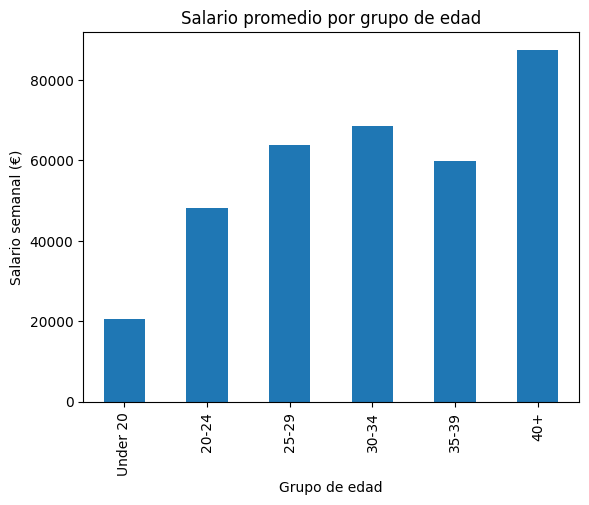

In [74]:
import matplotlib.pyplot as plt

df_filtrado.groupby('Age_group')['Weekly_Wages_EUR'].mean().plot(kind='bar')

plt.title("Salario promedio por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Salario semanal (€)")

plt.show()

<Axes: ylabel='Frequency'>

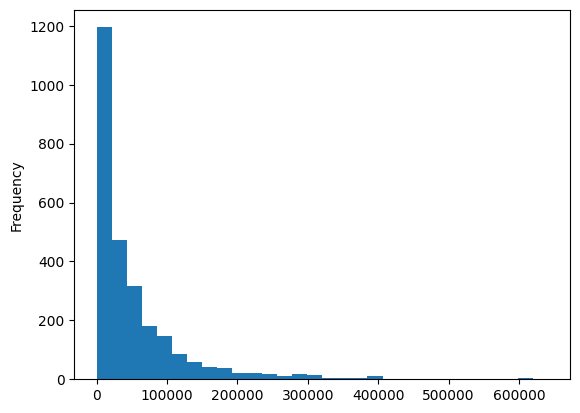

In [75]:
df_filtrado['Weekly_Wages_EUR'].plot(kind='hist', bins=30)

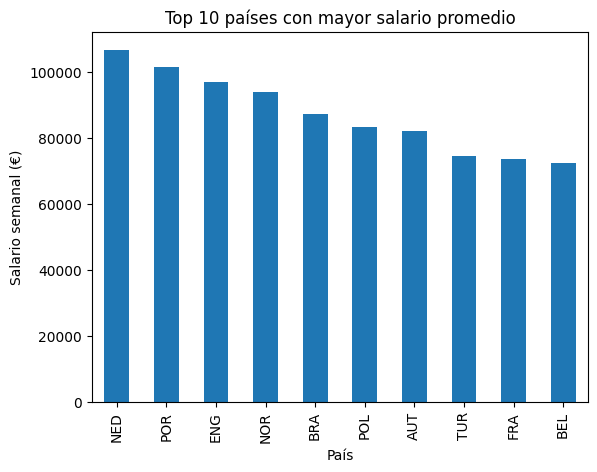

In [76]:
top_paises = df_paises.groupby('Nation_clean')['Weekly_Wages_EUR'].mean().sort_values(ascending=False).head(10)

top_paises.plot(kind='bar')

plt.title("Top 10 países con mayor salario promedio")
plt.xlabel("País")
plt.ylabel("Salario semanal (€)")

plt.show()

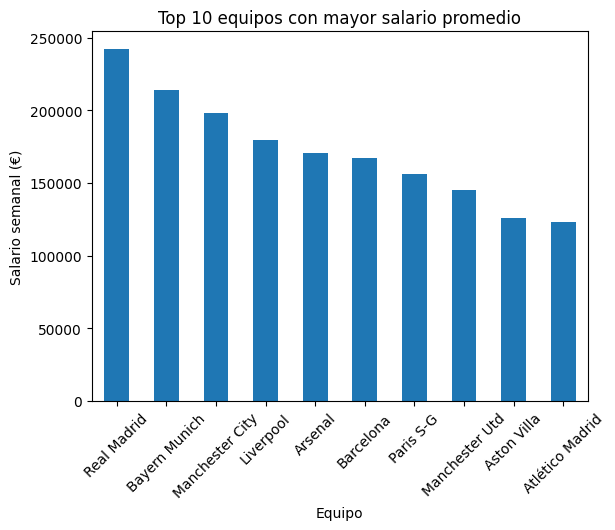

In [77]:
top_equipos = df_filtrado.groupby('Squad_x')['Weekly_Wages_EUR'].mean().sort_values(ascending=False).head(10)

top_equipos.plot(kind='bar')

plt.title("Top 10 equipos con mayor salario promedio")
plt.xlabel("Equipo")
plt.ylabel("Salario semanal (€)")

plt.xticks(rotation=45)

plt.show()

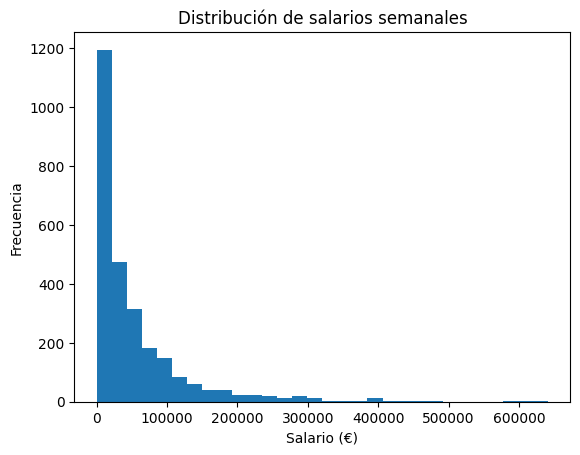

In [78]:
df_filtrado['Weekly_Wages_EUR'].plot(kind='hist', bins=30)

plt.title("Distribución de salarios semanales")
plt.xlabel("Salario (€)")
plt.ylabel("Frecuencia")

plt.show()

In [79]:
#La distribución de salarios presenta una asimetría positiva (sesgo a la derecha), lo que indica que la mayoría de los jugadores perciben salarios moderados, mientras que una minoría concentra salarios significativamente altos. Esto evidencia una fuerte desigualdad salarial dentro del fútbol profesional